Wyzwania:
dowiesz się, jaka jest różnica pomiędzy problemami, które już znasz a tekstem,
przekonasz się, dlaczego tekst to dane nieustrukturyzowane,
poznasz metody, które wykorzystywane są do stworzenia Chat Botów.
Zacznijmy od wczytania bibliotek, które zostaną wykorzystane w tym module.

In [2]:
!pip install nltk

     ---------------------------------------- 1.7/1.7 MB 3.8 MB/s eta 0:00:00
     -------------------------------------- 278.0/278.0 kB 3.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import string
import nltk
import itertools
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# 17.1 Elementy NLP

Uczenie maszynowe i przetwarzanie języka naturalnego (Natural Language Processing) to ważne części sztucznej inteligencji, które w ostatnich czasach zyskały na znaczeniu. Jest to bardzo szeroka dziedzina, zajmiemy się najpopularniejszymi stosowanymi technikami.

Dzięki postępom w dziedzinie przetwarzania języka naturalnego system sztucznie inteligentny może przyjmować lepsze informacje ze środowiska i współdziałać z człowiekiem, jeśli będzie go rozumiał. Niektóre z klasycznych przykładów wykorzystania uczenia maszynowego dla NLP to wykrywanie spamu. Wykrycie i sklasyfikowanie, czy wiadomość pocztowa jest odpowiednia, czy jest spamem, zawiera wiele niewiadomych. Filtry antyspamowe można omijać na wiele sposobów. Aby tradycyjny algorytm mógł działać, każda cecha i zmienna musi być zakodowana na sztywno, co jest niezwykle trudne, o ile w ogóle możliwe. Natomiast algorytm uczenia maszynowego będzie w stanie pracować w takim środowisku dzięki swojej zdolności do uczenia się i tworzenia ogólnych reguł. By algorytmy dla języka naturalnego potrafiły działać lepiej, stosowane są techniki przedstawione w tym module. Są one wykorzystywane razem z Głębokimi Sieciami Neuronowymi.

Z drugiej strony, przetwarzanie języka naturalnego to zdolność systemu do rozumienia i przetwarzania języków ludzkich. System komputerowy rozumie tylko język zer i jedynek, nie rozumie języków ludzkich, takich jak angielski czy polski. Przetwarzanie języka naturalnego dało systemowi komputerowemu możliwość rozumienia języków znanych ludziom.

Spójrzmy na możliwe zastosowania NLP.

# Tłumaczenie

Tłumaczenie języków obcych jest bardziej złożone niż prosta metoda zamiany słów. Ponieważ każdy język ma swoje reguły gramatyczne, wyzwaniem przy tłumaczeniu tekstu jest zrobienie tego bez zmiany jego znaczenia i stylu. Ponieważ komputery nie rozumieją gramatyki, potrzebują procesu, w którym mogą zdekonstruować zdanie, a następnie zrekonstruować je w innym języku w taki sposób, aby miało sens. Dobrym przykładem tłumaczenia tekstu na podstawie algorytmów sztucznej inteligencji jest narzędzie DeepL. Innym znanym Ci narzędziem jest dziecko firmy Google – Google Translate, które kiedyś wykorzystywało metodę PBMT (Phrase-Based Machine Translation). Polegała ona na wyszukiwaniu podobnych fraz dla różnych języków. Obecnie Google używa neuronowego tłumaczenia maszynowego Google (GNMT), które wykorzystuje ML i NLP do wyszukiwania wzorców w językach.

# Rozpoznawanie mowy

Rozpoznawanie mowy to zdolność maszyny do identyfikowania i interpretowania fraz i słów z języka mówionego oraz przekształcania ich w format czytelny dla maszyny. Wykorzystuje NLP, aby umożliwić komputerom symulowanie interakcji z ludźmi, oraz ML, aby reagować w sposób naśladujący ludzkie reakcje. Być może korzystasz na przykład z Siri. Wystarczy, że powiesz ‘zapisz w kalendarzu wizytę u fryzjera dziś o 16:00’ i nie musisz tego wpisywać własnoręcznie.

# Analiza sentymentu

Wykorzystywanie NLP i ML do interpretowania i analizowania emocji w artykułach bądź tweetach. Można zidentyfikować opinie pozytywne, negatywne i neutralne, aby określić nastawienie klienta do marki, produktu lub usługi. Analiza nastrojów jest wykorzystywana do oceny opinii publicznej, monitorowania reputacji marki i lepszego zrozumienia doświadczeń klientów. Przykładem możemy być sprawdzanie sentymentu dla artykułów biznesowych, na podstawie których próbować będziemy sprawdzać sentyment do danej spółki. Być może negatywny sentyment sprawi spadek ceny akcji tej firmy i będzie to dobry sygnał, aby sprzedać je czym prędzej!

# Chatboty

Są to programy służące do udzielania automatycznych odpowiedzi na typowe pytania klientów. Posiadają one systemy rozpoznawania wzorców z heurystycznymi odpowiedziami, które są wykorzystywane do prowadzenia rozmów z ludźmi. Początkowo chatboty były wykorzystywane do odpowiadania na podstawowe pytania, aby odciążyć centra telefoniczne i zaoferować szybką obsługę klienta. Jednak chatboty napędzane sztuczną inteligencją są zaprojektowane do obsługi bardziej skomplikowanych zapytań, dzięki czemu doświadczenia konwersacyjne stają się coraz bardziej intuicyjne. Gdy np. wybierasz się do największego centrum rozrywki w Europie, zauważ, że wiele pytań, które zadajesz, jest standardowych. Możesz zapytać czy konieczne jest kupienie biletu przez internet czy można zrobić to na miejscu. Jako odpowiedź otrzymasz "bilet możesz kupić online bądź na miejscu, jednak lepiej kupić online, ponieważ szybciej wejdziesz i będziesz mieć pewność wejścia".

Słowo „heurystyczny” oznacza oparty na praktycznych metodach, uproszczeniach lub intuicji, a nie na ścisłych, matematycznych dowodach.

# Klasyfikacja tekstu

Taka aplikacja to na przykład odróżnianie spamu od nie spamu, odróżnianie autora na podstawie tego w jaki sposób pisze.

# Automatyczne sprawdzanie gramatyki

Kolejną ważną częścią NLP jest automatyczne sprawdzanie gramatyki, czyli wykrywanie i poprawianie błędów gramatycznych i ortograficznych w tekście w zależności od kontekstu. Automatyczne sprawdzanie gramatyki poinformuje Cię o możliwym błędzie, podkreślając słowo na czerwono. Dobrym przykładem jest Grammarly, jeśli jeszcze nie masz ich wtyczki w przeglądarce to warto ją zainstalować.

# Generatywne Sieci Neuronowe (GAN - Generative Adversarial Networks)

Wyobraź sobie, że sieć neuronowa pisze nowe książki. Tak, jest to możliwe. Algorytm uczy się poprzednich książek danego autora i na podstawie tej nauki tworzy nowe dzieła. Nie zawsze jest to dobre, nie zawsze ma to sens, ale z pewnością jest to sztuczna inteligencja, o której większość ludzi myśli.

# 17.2. Przygotowanie danych tekstowych

Odpowiednio oczyszczone dane pomogą nam w przeprowadzeniu dobrej analizy tekstu i podejmowaniu trafnych decyzji dotyczących problemów biznesowych. Dlatego też wstępne przetwarzanie tekstu na potrzeby uczenia maszynowego jest bardzo ważnym krokiem. Dane tekstowe są nieuporządkowane. Nie mamy tutaj poszczególnych obserwacji (chyba, że za takie uważamy różne teksty), a na pewno nie ma tutaj określonej liczby cech. Poszczególne zdania mogą mieć różne znaczenia, tak samo jak słowa (przykładem słowo ‘klucz’).

In [4]:
spam_dataset = pd.read_csv('spam.csv', encoding = "ISO-8859-1", usecols=[0, 1], names=['Spam', 'Text'],
                           skiprows=1)
spam_dataset['Spam'] = spam_dataset['Spam'].replace(['ham', 'spam'], [0, 1])
spam_dataset

C:\Users\micha\AppData\Local\Temp\ipykernel_24288\1996902043.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spam_dataset['Spam'] = spam_dataset['Spam'].replace(['ham', 'spam'], [0, 1])


,Spam,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


Jesteś już po zajęciach z klasyfikacji, tutaj mamy właśnie ten problem – nie mamy jednak określonych cech, takich jak dla zbioru Titanic (wiek, opłata itd.), jest natomiast treść maila. Co tu warto sprawdzić? Sprawdźmy czy nasze klasy są zbalansowane!

In [5]:
print(spam_dataset['Spam'].value_counts(normalize=True))

Spam
0    0.865937
1    0.134063
Name: proportion, dtype: float64


Jak to w życiu, większość wiadomości to nie jest spam.

# Usuwanie znaków interpunkcyjnych

Jest to nic innego, jak rozpoczęcie wyczyszczenia tekstu, nad którym będziemy pracować.

Każdy ze znaków (takich jak kropka, przecinek, znak zapytania) używanych do dzielenia tekstu na zdania, klauzule itp. jest znany jako znak interpunkcyjny. Ogólnie rzecz biorąc, w gramatyce wyróżnić możemy te poniższe znaki:

'!"#$%&\'()*+,-./:;&lt;=>?@[\\]^_`{|}~'

by wybrać te znaki, korzystamy z biblioteki string i funkcji, która się tam znajduje, czyli punctuation. Zwraca ona powyższe znaki jako string. Na podstawie tego stworzymy funkcję, która będzie odrzucać wartości należące do znaków interpunkcyjnych.

In [9]:
def remove_puncation(text):                                                     # funkcja usuwająca znaki interpunkcyjne z tekstu
    cleaned = ''.join([word for word in text if word not in string.punctuation])# tworzenie nowego tekstu bez znaków interpunkcyjnych
    return cleaned                                                               # zwrócenie oczyszczonego tekstu

spam_dataset['Cleaned_Text'] = spam_dataset['Text'].apply(                      # dodanie nowej kolumny z oczyszczonym tekstem
    lambda x: remove_puncation(x))                                              # zastosowanie funkcji remove_puncation do każdej wiadomości

spam_dataset                                                                      # wyświetlenie całego DataFrame


,Spam,Text,Cleaned_Text
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?,Will Ì b going to esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",Pity was in mood for that Soany other suggest...
5570,0,The guy did some bitching but I acted like i'd...,The guy did some bitching but I acted like id ...


# Tokenizacja

Gdy już wyczyściliśmy tekst z wszelkich zbędnych znaków to powinniśmy podzielić go na poszczególne elementy. Komputer nie rozumie słów, zatem w kolejnych krokach będziemy zamieniać tekst na wektory. Jednak nie powinniśmy brać wszystkich wystąpień, ponieważ słowa takie jak ‘kochał’, ‘kochała’, ‘kochać’ czy ‘kocham’ oznaczają to samo.

Tokenizacja to proces dzielenia tekstu na mniejsze części zwane tokenami. Tymi mniejszymi częściami mogą być zdania, słowa lub podsłowa. Na przykład zdanie „Jestem zwycięzcą” możemy podzielić na [„jestem”, „zwycięzcą”].

Formalna definicja tokenów, według językoznawstwa, to "pojedyncze wystąpienie jednostki językowej w mowie lub piśmie, w odróżnieniu od rodzaju lub klasy jednostek językowych, których jest ona instancją". Tradycyjne metody tokenizacji obejmują tokenizację białych linii, interpunkcji lub tokenizację regex. Tokenizacja umożliwia maszynom odczytywanie tekstów. Zarówno tradycyjne, jak i oparte na głębokim uczeniu metody przetwarzania języka naturalnego w znacznym stopniu opierają się na tokenizacji. Jest ona często etapem wstępnego przetwarzania w większości aplikacji do przetwarzania języka naturalnego. Na przykład, aby policzyć liczbę słów w tekście, jest on dzielony za pomocą tokenizatorów. W głębokim uczeniu i metodach tradycyjnych tokenizacja jest wykorzystywana do inżynierii cech. Tokeny w naszym przypadku na ten moment to słowa występujące po sobie, aby proces był odporny na to, czy zdanie zaczyna się od słowa itd.

Teraz usuniemy wielkie litery. Ponownie stworzymy funkcję, którą następnie wykorzystamy.

Ponadto też każde słowo zamieniamy do małych liter, ponieważ zakładamy, że z semantycznego znaczenia duże litery na początku zdania nie przekazują informacji. Nie powinniśmy zatem też traktować osobno słów, które znajdują się na początku lub w środku zdania. Oczywiście w poszczególnych przypadkach może mieć to znaczenie, ale mamy nadzieję, że już wiesz, że za pomocą uczenia maszynowego musimy generalizować, a tym samym dążyć do zmniejszenia liczby cech. Na ten moment traktuj słowo jako poszczególną zmienną objaśniającą.

In [12]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

def tokenize(text):                                                             # funkcja do tokenizacji tekstu
    clean_text = text.lower()                                                   # zamiana na małe litery
    tokenized_text = nltk.word_tokenize(clean_text)                             # tokenizacja NLTK
    return tokenized_text                                                       # zwrócenie listy tokenów

spam_dataset['Tokenized_Text'] = spam_dataset['Cleaned_Text'].apply(            # utworzenie nowej kolumny
    lambda x: tokenize(x))                                                      # tokenizacja każdej wiadomości

spam_dataset                                                                     # wyświetlenie DataFrame


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


,Spam,Text,Cleaned_Text,Tokenized_Text
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l..."
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,This is the 2nd time we have tried 2 contact u...,"[this, is, the, 2nd, time, we, have, tried, 2,..."
5568,0,Will Ì_ b going to esplanade fr home?,Will Ì b going to esplanade fr home,"[will, ì, b, going, to, esplanade, fr, home]"
5569,0,"Pity, * was in mood for that. So...any other s...",Pity was in mood for that Soany other suggest...,"[pity, was, in, mood, for, that, soany, other,..."
5570,0,The guy did some bitching but I acted like i'd...,The guy did some bitching but I acted like id ...,"[the, guy, did, some, bitching, but, i, acted,..."


# Usuwanie stopwords

Stopwords to słowa w dowolnym języku, które nie wnoszą wiele do zdania. Można je bezpiecznie zignorować bez szkody dla znaczenia zdania. Dla niektórych wyszukiwarek są to najczęściej spotykane, krótkie słowa funkcyjne, takie jak "the", "is", "at", "which" i "on". W języku polskim może to być: "i", "czy", "gdy" i tak dalej, możemy wymieniać. Usuwanie takich słów powodować może też problemy podczas wyszukiwania fraz, które je zawierają, na przykład w bigramach (sekwencja 2 słów), takich jak "The Who" czy "Take That". Jeśli mamy do czynienia z klasyfikacją tekstu lub analizą nastrojów, powinniśmy usuwać stopwords, ponieważ nie wnoszą one żadnych informacji do naszego modelu, tzn. nie pozwalają usunąć niepożądanych słów z naszego korpusu, ale jeśli mamy do czynienia z tłumaczeniem języka, stop words są przydatne, ponieważ muszą zostać przetłumaczone wraz z innymi słowami. Nie ma jednoznacznej reguły, kiedy należy usuwać te słowa. Możemy jednak sugerować Ci usunięcie tych stopwords, jeśli naszym zadaniem jest klasyfikacja języka, filtrowanie spamu (jak w tym przypadku), analiza nastrojów lub coś, co jest związane z klasyfikacją tekstu.

Z drugiej strony, jeśli naszym zadaniem jest tłumaczenie maszynowe, udzielanie odpowiedzi na pytania, podsumowywanie tekstu czy modelowanie języka, lepiej nie usuwać stopwords, ponieważ stanowią one istotną część tych zastosowań.

Ponownie wykorzystajmy biblitekę nltk, tym razem do stworzenia listy ze stopwords.

In [14]:
import nltk
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words("english")
stopwords = nltk.corpus.stopwords.words("english")
stopwords
['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each',
 'few',
 'more',
 'most',
 'other',
 'some',
 'such',
 'no',
 'nor',
 'not',
 'only',
 'own',
 'same',
 'so',
 'than',
 'too',
 'very',
 's',
 't',
 'can',
 'will',
 'just',
 'don',
 "don't",
 'should',
 "should've",
 'now',
 'd',
 'll',
 'm',
 'o',
 're',
 've',
 'y',
 'ain',
 'aren',
 "aren't",
 'couldn',
 "couldn't",
 'didn',
 "didn't",
 'doesn',
 "doesn't",
 'hadn',
 "hadn't",
 'hasn',
 "hasn't",
 'haven',
 "haven't",
 'isn',
 "isn't",
 'ma',
 'mightn',
 "mightn't",
 'mustn',
 "mustn't",
 'needn',
 "needn't",
 'shan',
 "shan't",
 'shouldn',
 "shouldn't",
 'wasn',
 "wasn't",
 'weren',
 "weren't",
 'won',
 "won't",
 'wouldn',
 "wouldn't"]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

# ALTERNATYWA DLA nltk 

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
stopwords = list(ENGLISH_STOP_WORDS)

In [15]:
def remove_stopwords(text):
    without_stopwords = [word for word in text if word not in stopwords]
    return without_stopwords
spam_dataset['WithoutStop_Text'] = spam_dataset['Tokenized_Text'].apply(lambda x: remove_stopwords(x))
spam_dataset

,Spam,Text,Cleaned_Text,Tokenized_Text,WithoutStop_Text
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[go, until, jurong, point, crazy, available, o...","[go, jurong, point, crazy, available, bugis, n..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[u, dun, say, so, early, hor, u, c, already, t...","[u, dun, say, early, hor, u, c, already, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l...","[nah, dont, think, goes, usf, lives, around, t..."
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,This is the 2nd time we have tried 2 contact u...,"[this, is, the, 2nd, time, we, have, tried, 2,...","[2nd, time, tried, 2, contact, u, u, å£750, po..."
5568,0,Will Ì_ b going to esplanade fr home?,Will Ì b going to esplanade fr home,"[will, ì, b, going, to, esplanade, fr, home]","[ì, b, going, esplanade, fr, home]"
5569,0,"Pity, * was in mood for that. So...any other s...",Pity was in mood for that Soany other suggest...,"[pity, was, in, mood, for, that, soany, other,...","[pity, mood, soany, suggestions]"
5570,0,The guy did some bitching but I acted like i'd...,The guy did some bitching but I acted like id ...,"[the, guy, did, some, bitching, but, i, acted,...","[guy, bitching, acted, like, id, interested, b..."


# Stemming

est to proces tworzenia morfologicznych słów. Niejasne? Niektóre ze słów mają to samo znaczenie, a dokładniej to samo słowo podstawowe. Słowa ‘likely’, ‘liked’, ‘likes’ czy ‘liking’ zostaną zamienione w jedno słowo ‘like’. Dzięki technice stemming zmniejszamy liczbę wystąpień słowa do formy źródłowej tego słowa. W ten sposób normalizujemy tekst. Najprościej rzecz ujmując, stemming to proces usuwania części wyrazu lub sprowadzania wyrazu do jego rdzenia lub korzenia. Nie musi to oznaczać, że redukujemy słowo do jego słownikowego korzenia. W niektórych przypadkach wystąpią komplikacje i przez to możemy źle przekształcić słowo. Do tego ponownie skorzystajmy z biblioteki nltk.

In [17]:
stemmer = nltk.PorterStemmer()
def stemming(text):
    stemmed_words = [stemmer.stem(word) for word in text]
    return stemmed_words
spam_dataset['Stemmed_Text'] = spam_dataset['WithoutStop_Text'].apply(lambda x: stemming(x))
spam_dataset

,Spam,Text,Cleaned_Text,Tokenized_Text,WithoutStop_Text,Stemmed_Text
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[go, until, jurong, point, crazy, available, o...","[go, jurong, point, crazy, available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[free, entry, 2, wkly, comp, win, fa, cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[u, dun, say, so, early, hor, u, c, already, t...","[u, dun, say, early, hor, u, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l...","[nah, dont, think, goes, usf, lives, around, t...","[nah, dont, think, goe, usf, live, around, tho..."
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,This is the 2nd time we have tried 2 contact u...,"[this, is, the, 2nd, time, we, have, tried, 2,...","[2nd, time, tried, 2, contact, u, u, å£750, po...","[2nd, time, tri, 2, contact, u, u, å£750, poun..."
5568,0,Will Ì_ b going to esplanade fr home?,Will Ì b going to esplanade fr home,"[will, ì, b, going, to, esplanade, fr, home]","[ì, b, going, esplanade, fr, home]","[ì, b, go, esplanad, fr, home]"
5569,0,"Pity, * was in mood for that. So...any other s...",Pity was in mood for that Soany other suggest...,"[pity, was, in, mood, for, that, soany, other,...","[pity, mood, soany, suggestions]","[piti, mood, soani, suggest]"
5570,0,The guy did some bitching but I acted like i'd...,The guy did some bitching but I acted like id ...,"[the, guy, did, some, bitching, but, i, acted,...","[guy, bitching, acted, like, id, interested, b...","[guy, bitch, act, like, id, interest, buy, som..."


# Lematyzacja

Lematyzacja to inna technika przetwarzania tekstu. Zarówno w stemmingach, jak i w lematyzacji, próbujemy zredukować dane słowo do jego słowa źródłowego. W procesie stemmingu słowo źródłowe nazywane jest stemem, a w procesie lematyzacji - lematem. Jest jednak jeszcze kilka innych różnic między tymi dwoma procesami.

Czym różni się lematyzacja od stemmingu? W stemmingu część słowa jest po prostu odcinana na końcu, aby otrzymać rdzeń słowa. Istnieją oczywiście różne algorytmy ustalające, ile znaków należy odciąć, ale algorytmy te nie znają znaczenia słowa w języku, do którego ono należy. Z kolei w lematyzacji algorytmy dysponują taką wiedzą. Można nawet powiedzieć, że algorytmy te odwołują się do słownika, aby zrozumieć znaczenie słowa przed zredukowaniem go do wyrazu źródłowego, czyli lematu.

Tak więc algorytm lematyzacji wiedziałby, że słowo "better" pochodzi od słowa "good", a zatem lemat to "good". Algorytm stemmingowy nie byłby w stanie zrobić tego samego. Słowo "better" mogłoby zostać zredukowane do "bet", "bett" lub po prostu zachowane jako "better". Nie ma jednak możliwości, aby w procesie stemmingu słowo to zostało zredukowane do jego źródłosłowu "good". Na tym w zasadzie polega różnica między stemmingiem a lematyzacją. Jak możesz się domyślać, lamatyzacja może być lepszą techniką niż stemming.

Ponownie korzystamy z biblioteki nltk i tworzymy własną funkcję, która zlematyzuje tekst.

In [20]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')   # dodatkowy zasób wymagany przez lematyzator


lemmater = nltk.WordNetLemmatizer()
def lemmatizing(text):
    lemmatized_words = [lemmater.lemmatize(word) for word in text]
    return lemmatized_words
spam_dataset['Lemmatized_Text'] = spam_dataset['WithoutStop_Text'].apply(lambda x: lemmatizing(x))
spam_dataset

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...


,Spam,Text,Cleaned_Text,Tokenized_Text,WithoutStop_Text,Stemmed_Text,Lemmatized_Text
0,0,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,"[go, until, jurong, point, crazy, available, o...","[go, jurong, point, crazy, available, bugis, n...","[go, jurong, point, crazi, avail, bugi, n, gre...","[go, jurong, point, crazy, available, bugis, n..."
1,0,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,"[ok, lar, joking, wif, u, oni]","[ok, lar, joking, wif, u, oni]","[ok, lar, joke, wif, u, oni]","[ok, lar, joking, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f...","[free, entry, 2, wkly, comp, win, fa, cup, fin...","[free, entri, 2, wkli, comp, win, fa, cup, fin...","[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,"[u, dun, say, so, early, hor, u, c, already, t...","[u, dun, say, early, hor, u, c, already, say]","[u, dun, say, earli, hor, u, c, alreadi, say]","[u, dun, say, early, hor, u, c, already, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l...","[nah, dont, think, goes, usf, lives, around, t...","[nah, dont, think, goe, usf, live, around, tho...","[nah, dont, think, go, usf, life, around, though]"
...,...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,This is the 2nd time we have tried 2 contact u...,"[this, is, the, 2nd, time, we, have, tried, 2,...","[2nd, time, tried, 2, contact, u, u, å£750, po...","[2nd, time, tri, 2, contact, u, u, å£750, poun...","[2nd, time, tried, 2, contact, u, u, å£750, po..."
5568,0,Will Ì_ b going to esplanade fr home?,Will Ì b going to esplanade fr home,"[will, ì, b, going, to, esplanade, fr, home]","[ì, b, going, esplanade, fr, home]","[ì, b, go, esplanad, fr, home]","[ì, b, going, esplanade, fr, home]"
5569,0,"Pity, * was in mood for that. So...any other s...",Pity was in mood for that Soany other suggest...,"[pity, was, in, mood, for, that, soany, other,...","[pity, mood, soany, suggestions]","[piti, mood, soani, suggest]","[pity, mood, soany, suggestion]"
5570,0,The guy did some bitching but I acted like i'd...,The guy did some bitching but I acted like id ...,"[the, guy, did, some, bitching, but, i, acted,...","[guy, bitching, acted, like, id, interested, b...","[guy, bitch, act, like, id, interest, buy, som...","[guy, bitching, acted, like, id, interested, b..."


Na podstawie zlematyzowanych maili stwórzmy stringa, który jest połączeniem wszystkich słów dla maili, które są spamem oraz dla maili, które nie są spamem.

In [21]:
words_spam = list(spam_dataset.loc[spam_dataset['Spam']==1, 'Lemmatized_Text'].values)
words_spam = list(itertools.chain.from_iterable(words_spam))
words_spam = ' '.join(words_spam)
words_notspam = list(spam_dataset.loc[spam_dataset['Spam']==0, 'Lemmatized_Text'].values)
words_notspam = list(itertools.chain.from_iterable(words_notspam))
words_notspam = ' '.join(words_notspam)

Następnie tworzymy chmurę słów dla obu. Pewnie widzzdarzyło Ci się widzieć takie grafiki. Są one bardzo intuicyjne – im częściej słowo pojawia się w tekście, tym jest ono większe. Rozmiar poszczególnych słów jest zależny od tego, jak często dane słowo pojawia się w analizowanym tekście.

Najpierw chmura słów dla spamów.

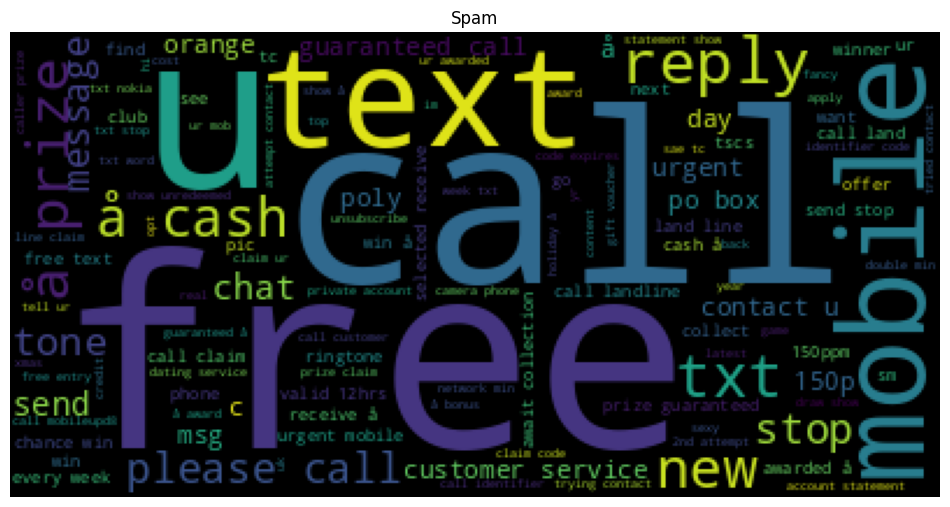

In [22]:
wordcloud = WordCloud().generate(words_spam)
plt.figure(figsize = (12, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Spam')
plt.show()

Teraz zróbmy to dla maili, które nie są spamem.

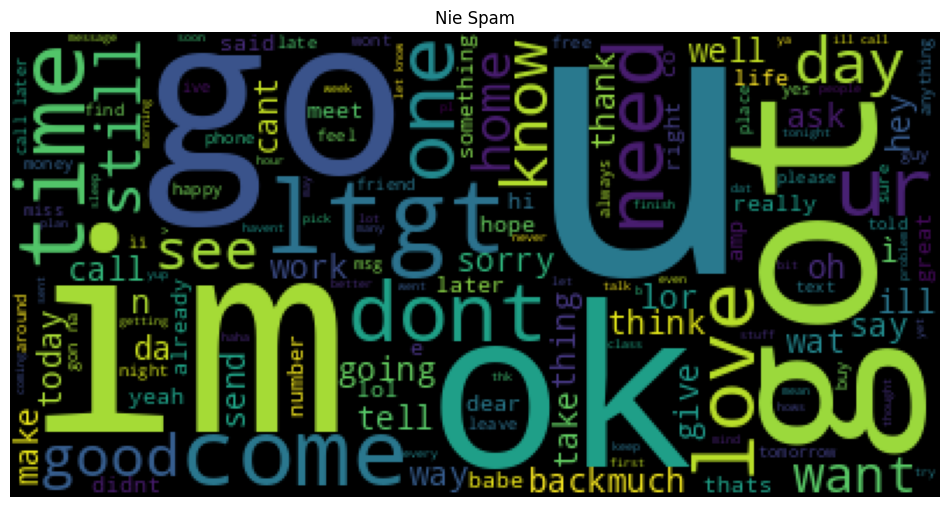

In [24]:
wordcloud = WordCloud().generate(words_notspam)
plt.figure(figsize = (12, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Nie Spam')
plt.show()

Wnioskiem może być na przykład to, że w mailach, które są spamem pojawiły się słowa takie jak ‘reply’, które nakazują odbiorcy pewną akcję.

# Wektoryzacja TF-IDF (Term frequency - Inverse document frequency)